# Lab 3: Sentinel-1 Time Series for Crop Growth in Midwest Row-Crop Fields

This notebook is for a lab on seasonal crop growth using Sentinel-1 SAR backscatter in large Midwestern U.S. fields.

The lab is designed to stay fully in Google Earth Engine + Python. We will be:

- building a consistent Sentinel-1 time series,
- selecting individual row-crop fields, forested regions, and towns/cities,
- extracting field-scale backscatter statistics,
- comparing seasonal trajectories,
- proposing a simple crop growth metric based on VV, VH, or VV/VH.

---

## Lab concept

Students will:

1. choose several individual regions in a Midwest US AOI. You do not have to choose a midwest US AOI, but it will be the easiest. Midwest US/Canada has perfectly North/South Aligned farms in 1.5 km grids, which uniformly grow corn/wheat/soy/etc. European farms are much smaller, and randomly oriented. Averaging over an entire field will increase the signal to noise ratio.
2. define field polygons as regions of interest,
3. build a seasonal Sentinel-1 time series,
4. compute field-level summary statistics for:
   - VV
   - VH
   - VV - VH (in dB is a convenient proxy related to VV/VH ratio)
5. interpret how those quantities evolve from:
   - bare ground / early season
   - vegetative growth
   - maturity
   - senescence (interesting fact - senescence progression is monitored via NDVI)
   - harvest

---

## Why the Midwest U.S.?

This is a good teaching region because many fields are:

- large,
- homogeneous,
- easy to outline,
- minimally affected by complex topography,
- dominated by row crops with strong seasonal structure.

That makes field-scale SAR time series much easier to interpret than small, irregular fields. Irregularly oriented fields produce an additional complexity with regards to geometry. You may have noticed when exploring Krakow SAR that the backscatter from farms could vary greatly. This can be due to differences in crop type, but it can also be related to how the rows are oriented with respect to the satellite look direction. Think about the ground texture of farms, there are many small ridges and valleys. If these ridges and valleys are parallel to the satellite look direction, backscatter will be weaker, and if the ridges and valleys are perpendicular to the satellite look direction, backscatter will be stronger.

---

## learning goals

By the end of this lab, students should be able to:

- explain why SAR time series must be filtered consistently,
- compute a field-averaged VV and VH time series,
- compare crop fields with a non-crop control,
- propose and defend simple crop growth metrics,
- explain why VH or VV-VH may respond differently from VV alone.

---

## 1. Imports and Earth Engine initialization

This notebook assumes that students already have:

- a working Python environment,
- the Earth Engine Python API,
- `geemap`,
- libraries `matplotlib` and `pandas`.

In [1]:
import ee
import geemap
import pandas as pd
import json
import matplotlib.pyplot as plt

PROJECT_ID = "useful-device-494108-c1"

try:
    ee.Initialize(project=PROJECT_ID)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)

print("Earth Engine initialized.")

Earth Engine initialized.


In [21]:
# Example AOI: large row-crop region in northern Iowa / southern Minnesota
aoi = ee.Geometry.Rectangle([-95.01, 44.04, -94.31, 43.54])

# Growing season year
YEAR = 2025

# Visualization parameters
vv_vis = {"min": -18, "max": 2}
vh_vis = {"min": -28, "max": -8}
ratio_vis = {"min": 2, "max": 12}

c1 = (43.54 + 44.04) / 2
c2 = (-94.31 + -95.01) / 2

m = geemap.Map(center=[c1, c2], zoom=11)
m.addLayer(aoi, {"color": "red"}, "AOI")
m

Map(center=[43.79, -94.66], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

## 3. Helper functions

To keep the notebook readable, the repetitive Earth Engine logic is collected into helper functions.

These functions do most of the work for:

- building a filtered Sentinel-1 collection,
- creating monthly composites,
- computing a convenient VV-VH metric,
- extracting region statistics through time.

---

### Why use `VV - VH` here?

Sentinel-1 GRD backscatter in Earth Engine is in dB.  
So for this lab, instead of using a raw linear ratio `VV/VH`, we use:

\[
VV - VH
\]

because in dB space this is directly related to the log-ratio and is easier to interpret consistently alongside VV and VH.


In [22]:
def get_s1_collection(start_date, end_date, region=aoi,
                      orbit_pass="ASCENDING",
                      mode="IW",
                      resolution=10):
    """Return a filtered Sentinel-1 GRD collection with VV and VH."""
    collection = (
        ee.ImageCollection("COPERNICUS/S1_GRD")
        .filterBounds(region)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.eq("instrumentMode", mode))
        .filter(ee.Filter.eq("orbitProperties_pass", orbit_pass))
        .filter(ee.Filter.eq("resolution_meters", resolution))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
        .select(["VV", "VH"])
    )
    return collection


def monthly_composite(year, month, region=aoi):
    """Return a monthly median Sentinel-1 image with a derived VV-VH band."""
    start = ee.Date.fromYMD(year, month, 1)
    end = start.advance(1, "month")

    collection = get_s1_collection(start, end, region=region)
    image = collection.median().clip(region)

    vv_minus_vh = image.select("VV").subtract(image.select("VH")).rename("VV_minus_VH")

    return (
        image.addBands(vv_minus_vh)
        .set({
            "year": year,
            "month": month,
            "system:time_start": start.millis(),
            "scene_count": collection.size()
        })
    )


def build_monthly_stack(year, months=range(3, 11), region=aoi):
    """Create a monthly ImageCollection for a growing season."""
    images = [monthly_composite(year, month, region=region) for month in months]
    return ee.ImageCollection(images)


def region_time_series(image_collection, region, scale=10):
    """Extract field-level mean VV, VH, and VV_minus_VH through time.

    Accepts either an ee.Geometry or an ee.Feature.
    """
    # If region is a Feature, convert it to its geometry
    if isinstance(region, ee.feature.Feature):
        region = region.geometry()

    def per_image(img):
        stats = img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=region,
            scale=scale,
            maxPixels=1e9,
            bestEffort=True
        )
        return ee.Feature(None, {
            "date": ee.Date(img.get("system:time_start")).format("YYYY-MM-dd"),
            "year": img.get("year"),
            "month": img.get("month"),
            "scene_count": img.get("scene_count"),
            "VV": stats.get("VV"),
            "VH": stats.get("VH"),
            "VV_minus_VH": stats.get("VV_minus_VH")
        })

    return ee.FeatureCollection(image_collection.map(per_image))

def fc_to_df(fc):
    """Convert an Earth Engine FeatureCollection of stats into a pandas DataFrame."""
    data = fc.getInfo()["features"]
    rows = [f["properties"] for f in data]
    df = pd.DataFrame(rows)
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"])
        df = df.sort_values("date").reset_index(drop=True)
    return df


## 4. Build a seasonal Sentinel-1 time series

We build monthly median images from February through November.

**QUESTION (5pts): What are the advantages and disadvantages of using monthly median stacks instead of relying on single scenes? In what circumstances would you not want to do any temporal averaging, and instead rely on single scenes?**

**ANSWER:**

*In my opinion using median stacks gives us more real representation of given timeframe of a region, imagery like this is not vulnerable to small fluctuations caused my some short even (eg. rain). Averaging also helps us to remove noise from imagery, giving us more real representation. In my opinion, temporal averaging should be used when we are looking for a trend in our imagery or more general events, no temporal averaging should be used, when we are analysing some rapidly occuring event, eg. fire, flooding etc.*

*Basically we can make temporal averaging while it is not working against our field of study, it can give us more accurate representation of region in some timeframe but also we can loose important event.*

**QUESTION (5pts): Why do we filter Sentinel-1 by orbit direction, instrument mode, polarization, and resolution before building the time series? What might happen if ascending and descending passes were mixed in the same time series?**

**ANSWER:**

*Not doing this would basically cause comparing imagery with completely different characteristics. There is not much sense in doing this in this way, we won't obtain accurate results.*

*We are doing this to make sure each acquired scene was obtained with same conditions, ascending and descending directions are completely different, backscatter will differ even if land has not changed so far. Differences in instrument mode, polarization and resolution also can cause differences in acquired imagery causing fluctuations in VV, VH, VV-VH values making comparison not reliable.* 


In [23]:
months = list(range(2, 12))  # February through November
monthly_stack = build_monthly_stack(YEAR, months=months, region=aoi)

print("Monthly images in stack:", monthly_stack.size().getInfo())

# Check how many scenes contribute to each month
for month in months:
    img = monthly_composite(YEAR, month, aoi)
    print(f"Month {month:02d}: {ee.Number(img.get('scene_count')).getInfo()} scenes")


Monthly images in stack: 10
Month 02: 8 scenes
Month 03: 8 scenes
Month 04: 10 scenes
Month 05: 4 scenes
Month 06: 3 scenes
Month 07: 3 scenes
Month 08: 4 scenes
Month 09: 2 scenes
Month 10: 4 scenes
Month 11: 4 scenes


## 5. Quick visual inspection

Before drawing fields, it is useful to inspect one or two monthly composites.

Suggested things to look for:

- field texture,
- strong contrasts between different fields,
- stable non-crop controls such as roads, towns, or tree patches.

**QUESTION (10pts): Compare an early month with a peak month visually. Feel free to change the months plotted, or add in comparisons of early vs mid- season VV_minus_VH, for your investigations. Take particular note of how much VH changes vs how much VV changes. What regions do you think you will choose for your ROI's and why? If you want an extra challenge (but not necessary), try to find a field you think was tall crops, a field you think was short crops, and a field you think was left barren.**

**ANSWER:**

*We see a major change both in VV and VH, I am comparing February and July*

*More significant change is visible in VH, it is caused by crop growth, development of the plants causes bigger backscatter, this is directly connected to peak of plants volume that is occuring in July, more developed biomass causes VH growth.*
*We see different changes in farmlads, some crops are giving higher VH, some lower VH, it is propably caused by type of plants that are growing there. Eg. corn will produce higher VH than wheats.*

*We see also VV change, but it is not as noticeable as VH growth, plants cause VV to be bigger than in case of bare soil, that change is however not as significant as VH change.*

*As ROI's I will choose some crops, city (Mountain Lake or Saint James) and forest, eg. Cedar Creek Park. I think in city and forest we won't experience huge change in comparison with farmlands.*

In [24]:
img_early = monthly_composite(YEAR, 2, aoi)
img_peak = monthly_composite(YEAR, 7, aoi)

#YOUR CODE HERE: The lines above grab the montlhy composite images for February and July. I want you to plot a split_map image of the VH channel in this cell, and in the cell below plot a split_map image of the VV channel for the same months.
m = geemap.Map(center=[c1, c2], zoom=11)
m.split_map(
    left_layer=geemap.ee_tile_layer(img_early.select("VH"), vh_vis, "VH February"),
    right_layer=geemap.ee_tile_layer(img_peak.select("VH"), vh_vis, "VH July")
)
display(m)
#m.addLayer(aoi, {"color": "red"}, "AOI")

Map(center=[43.79, -94.66], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_…

In [25]:
#Plot the VV split_map here.

m = geemap.Map(center=[c1, c2], zoom=11)
m.split_map(
    left_layer=geemap.ee_tile_layer(img_early.select("VV"), vv_vis, "VV February"),
    right_layer=geemap.ee_tile_layer(img_peak.select("VV"), vv_vis, "VV July")
)
display(m)

Map(center=[43.79, -94.66], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_…

In [26]:
# VV-VH
m = geemap.Map(center=[c1, c2], zoom=11)
m.split_map(
    left_layer=geemap.ee_tile_layer(img_early.select("VV_minus_VH"), ratio_vis, "VV-VH February"),
    right_layer=geemap.ee_tile_layer(img_peak.select("VV_minus_VH"), ratio_vis, "VV-VH July"),
)
display(m)

Map(center=[43.79, -94.66], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_…

# 6. Draw field polygons

Use the map drawing tools to create several polygons:

- at least **two different crop fields**
- at least **two control areas** (1 patch of trees, 1 city or town)

### Suggested strategy
Pick fields that are:

- large,
- internally uniform,
- clearly separated from neighboring fields.

After drawing polygons on the map, export them to Earth Engine objects.

**NOTE: You will need to remember the order of the ROI's you chose. For example, remember that you first chose three farm fields, then a tree stand, then the city/town. In the next section, you will need to assign these drawn features to variables and a dictionary.**



In [ ]:
m = geemap.Map(center=[c1, c2], zoom=12)
m.addLayer(img_peak.select("VV"), vv_vis, "VV July")
m.addLayer(img_peak.select("VH"), vh_vis, "VH July")
#m.addLayer(aoi, {"color": "red"}, "AOI")

#m.addLayer(ee.Geometry.Rectangle([-94.592184, 43.833392, -94.572314, 43.818920]), {"color": "green"}, "Farm #1")
#m.addLayer(ee.Geometry.Rectangle([-94.794144, 43.769129, -94.784323, 43.761975]), {"color": "green"}, "Farm #2")
#m.addLayer(ee.Geometry.Rectangle([-94.654289, 43.819485, -94.644417, 43.815874]), {"color": "green"}, "Farm #3")

#m.addLayer(ee.Geometry.Rectangle([-94.492088, 43.609726, -94.481188, 43.606435]), {"color": "red"}, "Cedar Creek Park")
#m.addLayer(ee.Geometry.Rectangle([-94.640436, 43.993696, -94.606705, 43.972390]), {"color": "blue"}, "Saint James")
m

# After drawing polygons with the map tools, use:
# drawn_fc = m.draw_features

Map(center=[43.79, -94.66], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

In [43]:
drawn_fc = m.draw_features
print(drawn_fc)

[<ee.feature.Feature object at 0x15a212270>, <ee.feature.Feature object at 0x15a213f80>, <ee.feature.Feature object at 0x15a213bc0>, <ee.feature.Feature object at 0x15a210800>, <ee.feature.Feature object at 0x15a2108f0>]


## 7. Make sure your drawn features are where you want them.

To do this, you will need to need to adjust the code below to match the order and number of ROI's you chose to investigate.


In [ ]:
# Example fallback polygons
#field_1 = ee.Geometry.Rectangle([-93.731, 43.949, -93.714, 43.964])
#field_2 = ee.Geometry.Rectangle([-93.666, 43.865, -93.646, 43.882])
#control_1 = ee.Geometry.Rectangle([-93.585, 43.971, -93.571, 43.982])  # mixed non-crop / built area
field_1 = drawn_fc[0]
field_2 = drawn_fc[1]
field_3 = drawn_fc[2]
trees_1 = drawn_fc[3]
control_1 = drawn_fc[4]
roi_dict = {
    "Field_1": field_1,
    "Field_2": field_2,
    "Field_3": field_3,
    "Trees_1": trees_1,
    "Control_1": control_1
}

m = geemap.Map(center=[43.9, -93.6], zoom=12)
m.addLayer(img_peak.select("VV"), vv_vis, "VV July")
for name, geom in roi_dict.items():
    m.addLayer(geom, {"color": "yellow"}, name)
m

##PLEASE PASTE THE OUTPUT OF THIS AS A COMMENT HERE SO THAT I KNOW WHICH ROI's YOU CHOSE
# #Field_1 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-94.592242, 43.818954], [-94.592242, 43.833412], [-94.572287, 43.833412], [-94.572287, 43.818954], [-94.592242, 43.818954]]]}
# #Field_2 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-94.654341, 43.815919], [-94.654341, 43.819511], [-94.644384, 43.819511], [-94.644384, 43.815919], [-94.654341, 43.815919]]]}
# #Field_3 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-94.794202, 43.761951], [-94.794202, 43.769141], [-94.784245, 43.769141], [-94.784245, 43.761951], [-94.794202, 43.761951]]]}
# #Trees_1 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-94.492164, 43.606406], [-94.492164, 43.609731], [-94.48122, 43.609731], [-94.48122, 43.606406], [-94.492164, 43.606406]]]}
# #Control_1 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-94.640522, 43.972249], [-94.640522, 43.993802], [-94.606705, 43.993802], [-94.606705, 43.972249], [-94.640522, 43.972249]]]}
for name, roi in roi_dict.items():
    print(name, roi.geometry().getInfo())


Field_1 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-94.592242, 43.818954], [-94.592242, 43.833412], [-94.572287, 43.833412], [-94.572287, 43.818954], [-94.592242, 43.818954]]]}
Field_2 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-94.654341, 43.815919], [-94.654341, 43.819511], [-94.644384, 43.819511], [-94.644384, 43.815919], [-94.654341, 43.815919]]]}
Field_3 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-94.794202, 43.761951], [-94.794202, 43.769141], [-94.784245, 43.769141], [-94.784245, 43.761951], [-94.794202, 43.761951]]]}
Trees_1 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-94.492164, 43.606406], [-94.492164, 43.609731], [-94.48122, 43.609731], [-94.48122, 43.606406], [-94.492164, 43.606406]]]}
Control_1 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-94.640522, 43.972249], [-94.640522, 43.993802], [-94.606705, 43.993802], [-94.606705, 43.972249], [-94.640522, 43.972249]]]}


## 8. Extract time series for each field

For each ROI, compute a field-mean time series of:

- VV
- VH
- VV - VH

This is the core analysis step of the lab.

In [52]:
ts_dict = {}

for name, geom in roi_dict.items():
    fc = region_time_series(monthly_stack, geom, scale=10)
    df = fc_to_df(fc)
    ts_dict[name] = df

    print(name)
    print(df)
    print("--------------------------------")


Field_1
          VH         VV  VV_minus_VH       date  month  scene_count  year
0 -27.656728 -15.109276    12.547452 2025-02-01      2            8  2025
1 -26.054926 -14.484076    11.570850 2025-03-01      3            8  2025
2 -26.738043 -15.051515    11.686529 2025-04-01      4           10  2025
3 -26.898338 -16.308264    10.590073 2025-05-01      5            4  2025
4        NaN        NaN          NaN 2025-06-01      6            3  2025
5 -16.498890  -9.367714     7.131176 2025-07-01      7            3  2025
6 -16.496798  -8.883415     7.613383 2025-08-01      8            4  2025
7 -17.322938 -10.056132     7.266806 2025-09-01      9            2  2025
8 -25.921508 -14.087580    11.833928 2025-10-01     10            4  2025
9 -25.399929 -14.202261    11.197668 2025-11-01     11            4  2025
--------------------------------
Field_2
          VH         VV  VV_minus_VH       date  month  scene_count  year
0 -31.230080 -18.242048    12.988032 2025-02-01      2         

**QUESTION (5pts): Which month has the minimum VH? Which month has the maximum VH? Does this match what you expected from the image comparison?**

**ANSWER:**

*The results are not surprising, we see lowest VV-VH value (thus highest VH) in July. This is happening in the areas of farmlands, for Trees and Control (city) areas we see much more stable VV-VH readings during whole year.*

*Minimum VH is obtained in february, maximum VH is obtained in July.*

## 9. Plot VV, VH, and VV-VH through time

These plots are where the crop-growth story should begin to emerge.

**QUESTION (20pts):**
- Qualitatively compare your three different types of ROI's (1) farms; (2) trees; and (3) towns. A few sentences to a short paragraph is enough.
- Based on these plots, identify the months that (1) crops started growing; (2) crops stopped growing; and (3) crops were harvested.
- Does VV-VH separate crops from control AOI's better than VV alone?
- Which ROI looks least like an actively growing crop field?
- Which ROI shows the strongest seasonal change in VH? Which ROI is most stable through time? Explain whether each behavior is more consistent with crop growth, forest canopy, or built-up land.

**ANSWER:**

1. Qualitatively compare your three different types...

*After taking holistic look on the resulting graphs we can clearly distinct different types of values for given ROI's. First let address the VV during the year. Control and Trees ROI's seem to hold relativelty stable and constant VV value during the whole year, with small fluctuations only. On the other hand farmlands tend to have low VV during non growth months, bumping its value to values similar to Trees and Control ROI's during the growth and pre-harvest phase.*

*Same thing happens with VH, VH tends to be high and constant for Control and Trees ROI's, while in farmlands it spikes during the growth and pre-harvest phase. We can also clearly see that this change is much more intense and distinct than VV. We see values changes from approx -30dB to -18dB in growth peak, much bigger change than in VV (-16dB -> -12dB)*

2. Based on these plots, identify the months...

*Looks like the growth is starting happening in april/may achieving its peak on july/august and in september/october we see sudden change, thus probably harvest*

3. Does VV-VH separate crops from control AOI's better than VV alone?

*I think VV-VH is better, because it combines both VV and VH depicting the change that occurs during growth phase in both values with respect to bigger VH change.*

4. Which ROI looks least like an actively growing crop field?

*The city one, significant changes cannot be seen here.*

5. Which ROI shows the strongest seasonal change in VH? Which ROI is most stable through time? Explain whether each behavior is more consistent with crop growth, forest canopy, or built-up land.

*Field 3 shows strongest seasonal change in VH, city is most stable while forest is relatively constant over time also.*

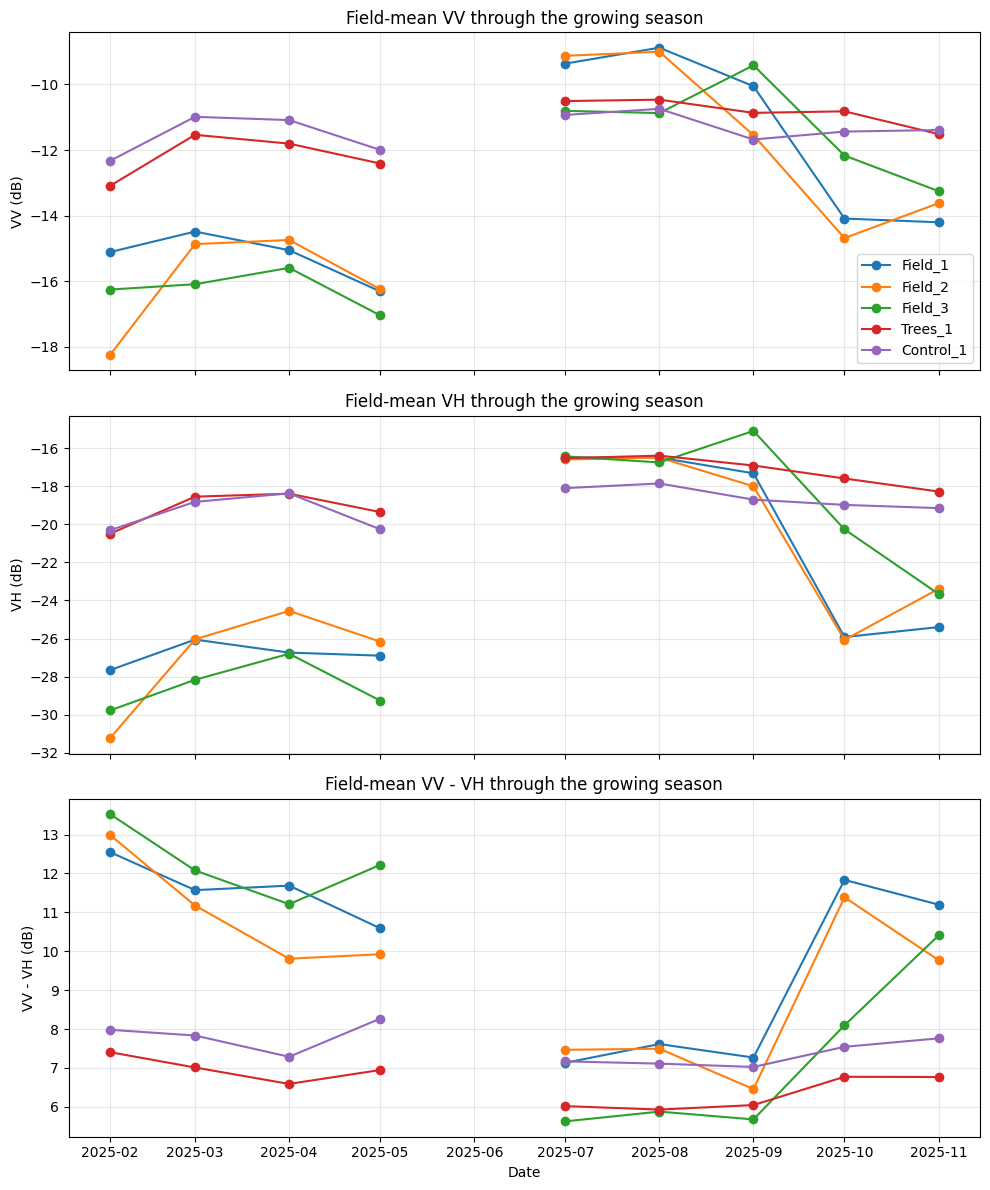

In [53]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

for name, df in ts_dict.items():
    axes[0].plot(df["date"], df["VV"], marker="o", label=name)
    axes[1].plot(df["date"], df["VH"], marker="o", label=name)
    axes[2].plot(df["date"], df["VV_minus_VH"], marker="o", label=name)

axes[0].set_title("Field-mean VV through the growing season")
axes[0].set_ylabel("VV (dB)")
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Field-mean VH through the growing season")
axes[1].set_ylabel("VH (dB)")
axes[1].grid(True, alpha=0.3)

axes[2].set_title("Field-mean VV - VH through the growing season")
axes[2].set_ylabel("VV - VH (dB)")
axes[2].set_xlabel("Date")
axes[2].grid(True, alpha=0.3)

axes[0].legend()
plt.tight_layout()
plt.show()


## 10. Build a simple crop-growth metric

Next I want you to propose a metric that captures crop development.

Possible first ideas include:

- peak VH minus spring VH,
- July VH minus April VH,
- maximum seasonal VV-VH range,
- cumulative increase from planting to peak growth.

Below is one simple example:

\[
Growth Metric = VH_{peak} - VH_{early}
\]

This is not necessarily the best metric — it is just a starting point.



In [ ]:
def calculate_vh_diff_metrics(df):
    return df.loc[df['month'] == 7]['VH'].values[0] - df.loc[df['month'] == 2]['VH'].values[0]

def calculate_vv_vh_diff_metrics(df):
    return  df.loc[df['month'] == 2]['VV_minus_VH'].values[0] - df.loc[df['month'] == 7]['VV_minus_VH'].values[0]

for name, df in ts_dict.items():
    print(f"{name}:")
    print(f"Simple : {calculate_vh_diff_metrics(df)}")
    print(f"VV-VH  : {calculate_vv_vh_diff_metrics(df)}")
    print("---")



Field_1:
Simple : 11.157838451061
VV-VH  : -5.416276748970651
---
Field_2:
Simple : 14.633189112917755
VV-VH  : -5.522252145059648
---
Field_3:
Simple : 13.341690841990665
VV-VH  : -7.898227772644979
---
Trees_1:
Simple : 3.968385206000047
VV-VH  : -1.3867584829083341
---
Control_1:
Simple : 2.209175909645918
VV-VH  : -0.81143201920528
---


## 11. Optional: compare fields spatially for one month

It is often useful to look at the mapped field values in the month of strongest contrast.

This can help connect your field-average statistics back to the actual imagery.


In [ ]:
img_july = monthly_composite(YEAR, 7, aoi)

m = geemap.Map(center=[43.9, -93.6], zoom=12)
m.addLayer(img_july.select("VV"), vv_vis, "VV July")
m.addLayer(img_july.select("VH"), vh_vis, "VH July")
m.addLayer(img_july.select("VV_minus_VH"), ratio_vis, "VV-VH July")

for name, geom in roi_dict.items():
    m.addLayer(geom, {"color": "yellow"}, name)

m

## 12. Optional: identify likely tall vs shorter crops

With Sentinel-1 alone, you should not make an overconfident crop-type classification.  
But you can propose that one field is more consistent with a tall, strongly volume-scattering canopy than another.

For example:
- stronger seasonal VH increase,
- larger mid-season drop in VV-VH,
- more pronounced growth curve.


## Final note
This lab is designed to connect a simple SAR observable to a real seasonal process.  
The goal is not perfect crop classification, but rather to help reason from:

- backscatter,
- polarization,
- time,
- and field geometry

toward a physically grounded interpretation of crop growth.
